In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Loading the series matrix file
filepath = "../data/GSE2034_series_matrix.txt"

# Reading metadata lines (they start with !)
metadata = {}
with open(filepath, 'r') as f:
    for line in f:
        if line.startswith('!'):
            parts = line.strip().split('\t')
            metadata[parts[0]] = parts[1:]
        elif line.startswith('"ID_REF"'):
            break

print(f"Number of metadata fields: {len(metadata)}")
print("\nSample metadata keys:")
for key in list(metadata.keys())[:10]:
    print(key)

Number of metadata fields: 50

Sample metadata keys:
!Series_title
!Series_geo_accession
!Series_status
!Series_submission_date
!Series_last_update_date
!Series_pubmed_id
!Series_summary
!Series_type
!Series_sample_id
!Series_contact_name


In [4]:
# Loading the expression data
expr_df = pd.read_csv(filepath, 
                      sep='\t', 
                      comment='!',
                      index_col=0)

# Removing the last row if it's a footer
expr_df = expr_df[expr_df.index != '"ID_REF"']

print(f"Shape: {expr_df.shape}")
print(f"\nNumber of genes: {expr_df.shape[0]}")
print(f"Number of samples: {expr_df.shape[1]}")
print(f"\nFirst few rows:")
expr_df.head()

Shape: (22283, 286)

Number of genes: 22283
Number of samples: 286

First few rows:


,GSM36777,GSM36778,GSM36779,GSM36780,GSM36781,GSM36782,GSM36783,GSM36784,GSM36785,GSM36786,...,GSM37053,GSM37054,GSM37055,GSM37056,GSM37057,GSM37058,GSM37059,GSM37060,GSM37061,GSM37062
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,3848.1,6520.9,5285.7,4043.7,4263.6,2949.8,5498.9,3863.1,3370.4,3991.9,...,4058.2,4017.6,2841.0,2914.2,3681.0,3066.9,2773.0,2984.3,3540.0,2620.0
1053_at,228.9,112.5,178.4,398.7,417.7,221.2,280.4,198.2,304.7,198.2,...,183.4,356.1,234.6,169.4,94.5,265.5,209.8,160.0,285.7,180.5
117_at,213.1,189.8,269.7,312.4,327.1,225.0,243.5,244.4,348.5,185.3,...,326.6,234.9,369.6,149.5,236.4,347.9,226.7,252.9,135.1,191.8
121_at,1009.4,2083.3,1203.4,1104.4,1043.3,1117.6,1085.4,1423.1,1196.4,993.3,...,1041.3,1195.6,751.5,1117.8,1022.4,1127.4,1071.8,1178.5,1256.7,1284.6
1255_g_at,31.8,145.8,42.5,108.2,69.2,47.4,84.3,102.0,22.8,86.3,...,143.5,32.7,62.6,43.0,100.5,47.0,45.1,146.3,75.9,87.4


22,283 genes (rows) - each one is a probe measuring a gene's activity

286 patients (columns) - each GSM number is one breast cancer patient

The numbers are expression values - how active each gene is in that patient

In [5]:
# Extracting relapse information from metadata
sample_ids = metadata['!Sample_geo_accession']
relapse = metadata['!Sample_characteristics_ch1']

# Building a clinical dataframe
clinical_df = pd.DataFrame({
    'sample_id': sample_ids,
    'relapse': relapse
})

# Cleaning up the values
clinical_df['relapse'] = clinical_df['relapse'].str.replace('"', '')

print(clinical_df['relapse'].value_counts())
print(f"\nFirst few rows:")
clinical_df.head()

relapse
bone relapses (1=yes, 0=no): 0    217
bone relapses (1=yes, 0=no): 1     69
Name: count, dtype: int64

First few rows:


,sample_id,relapse
0,"""GSM36777""","bone relapses (1=yes, 0=no): 0"
1,"""GSM36778""","bone relapses (1=yes, 0=no): 0"
2,"""GSM36779""","bone relapses (1=yes, 0=no): 0"
3,"""GSM36780""","bone relapses (1=yes, 0=no): 0"
4,"""GSM36781""","bone relapses (1=yes, 0=no): 0"


217 patients who did NOT relapse (0)

69 patients who DID relapse (1)

This is our key variable - we'll use this to find which genes behave differently between these two groups.

In [6]:
# Cleaning up sample IDs and relapse labels
clinical_df['sample_id'] = clinical_df['sample_id'].str.replace('"', '')
clinical_df['relapse'] = clinical_df['relapse'].str.extract(r'(\d)$').astype(int)

print(clinical_df['relapse'].value_counts())
print(f"\nFirst few rows:")
clinical_df.head()

relapse
0    217
1     69
Name: count, dtype: int64

First few rows:


,sample_id,relapse
0,GSM36777,0
1,GSM36778,0
2,GSM36779,0
3,GSM36780,0
4,GSM36781,0


Now we have:

Sample IDs without the messy quotes

Relapse as simple 0 and 1

/var/folders/mf/j5gm3bg91kd4ypxbn542lsk00000gn/T/ipykernel_2507/4106592001.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=clinical_df, x='relapse', palette=['steelblue', 'salmon'])


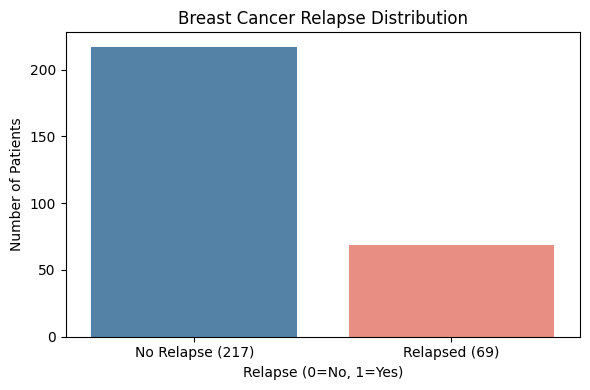

Plot saved!


In [7]:
# Visualize relapse distribution (simple count plot showing the balance between relapsed and non-relapsed patients)
plt.figure(figsize=(6, 4))
sns.countplot(data=clinical_df, x='relapse', palette=['steelblue', 'salmon'])
plt.title('Breast Cancer Relapse Distribution')
plt.xlabel('Relapse (0=No, 1=Yes)')
plt.ylabel('Number of Patients')
plt.xticks([0, 1], ['No Relapse (217)', 'Relapsed (69)'])
plt.tight_layout()
plt.savefig('../data/relapse_distribution.png', dpi=150)
plt.show()
print("Plot saved!")

In [10]:
# PCA plot — will show us visually whether relapsed and non-relapsed patients have different gene expression patterns overall.
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Aligning samples between expression and clinical data
expr_df.columns = expr_df.columns.str.replace('"', '')
common_samples = clinical_df['sample_id'].tolist()
expr_aligned = expr_df[common_samples].T  # samples as rows, genes as columns

# Scaling the data
scaler = StandardScaler()
expr_scaled = scaler.fit_transform(expr_aligned)

# Running PCA
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(expr_scaled)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")

Variance explained by PC1: 7.01%
Variance explained by PC2: 5.16%


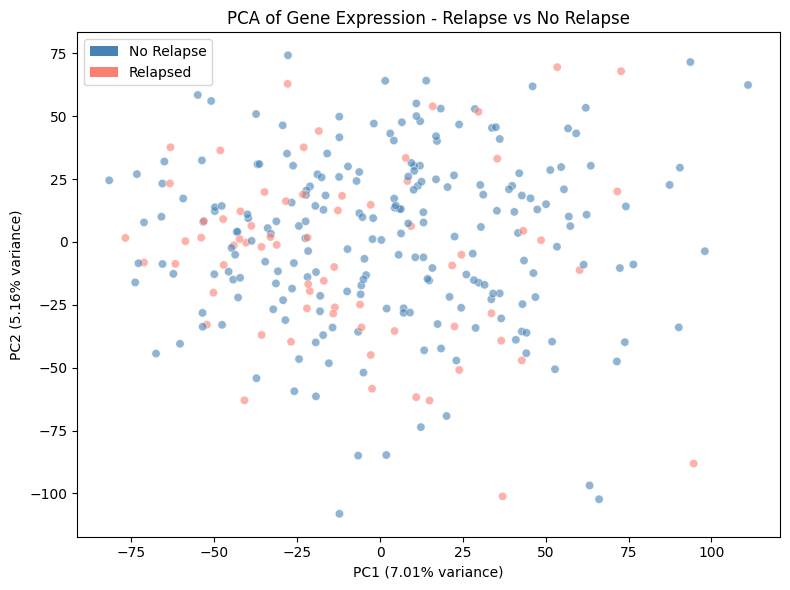

PCA plot saved


In [12]:
# Plot PCA
plt.figure(figsize=(8, 6))

colors = clinical_df['relapse'].map({0: 'steelblue', 1: 'salmon'})
plt.scatter(pca_coords[:, 0], pca_coords[:, 1], 
            c=colors, alpha=0.6, edgecolors='white', linewidth=0.5)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='No Relapse'),
                   Patch(facecolor='salmon', label='Relapsed')]
plt.legend(handles=legend_elements)

plt.title('PCA of Gene Expression - Relapse vs No Relapse')
plt.xlabel(f'PC1 (7.01% variance)')
plt.ylabel(f'PC2 (5.16% variance)')
plt.tight_layout()
plt.savefig('../data/pca_plot.png', dpi=150)
plt.show()
print("PCA plot saved")

how blue and pink dots are mixed together tells us something really interesting biologically - relapse vs no relapse can't be separated by just the top 2 principal components. The difference between these patients is subtle and spread across many genes, not driven by a few obvious ones.

This is exactly why we need differential expression analysis - to systematically find which specific genes are different.